In [2]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import numpy as np

from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns

In [3]:
data = pd.read_csv('../data/raw/05_FMBA24sf2_clean_250620_n3754.csv', sep='\t')
metadata = pd.read_csv('../data/raw/05_FMBA24sf2_meta_250620.csv', sep='\t')
metadata = metadata.set_index('colname')

## Look at the data

First we will look at what data we have. What kind of variables, how many samples, and how complete is the data. We have some information about the variables in the metadata file. 

In [ ]:
data_columns = data.columns.tolist()

questions_info = []

for col_name in data_columns:
    question_text = 'N/A'
    response_options = 'N/A'

    if col_name in metadata.index:
        if 'questn' in metadata.columns:
            question_text = metadata.loc[col_name, 'questn']
        
        if 'values' in metadata.columns and pd.notna(metadata.loc[col_name, 'values']):
            response_options = metadata.loc[col_name, 'values']
        elif 'type' in metadata.columns:
            response_options = metadata.loc[col_name, 'type']
        else:
            response_options = 'Not explicitly listed in metadata'
    
    questions_info.append({
        'Variable Name': col_name,
        'Question Asked': question_text,
        'Response Options': response_options
    })

questions_df = pd.DataFrame(questions_info)

# Print the DataFrame in a markdown table format for easy readability by an LLM
# print(questions_df.to_markdown(index=False))

| Variable Name                | Question Asked                                                                                                                                                                                                                                                                                                                                                                  | Response Options                                                                                                                                                                                                                                 |
|:-----------------------------|:---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3754 entries, 0 to 3753
Columns: 180 entries, fmba_campaign_year to geometry
dtypes: bool(6), float64(69), int64(2), object(103)
memory usage: 5.0+ MB


### Advice column

In [5]:
treatment_varname = 'previousadvice'
metadata.loc[treatment_varname]

colindex                                                      6
coltype                                               character
n_distinct                                                    2
n_missing                                                     0
mean                                                        NaN
median                                                      NaN
min                                                         NaN
max                                                         NaN
type                                                 select_one
values                                                 yes / no
questn        Advice with phone last season?\r\r\nWas Farmer...
Name: previousadvice, dtype: object

Now, the data is collected through a survey, so let's see what what that variable is the answer to.

In [6]:
metadata.loc[treatment_varname, 'questn']

'Advice with phone last season?\r\r\nWas Farmer-MBA advice given to you for the 2023-24 season?'

In [7]:
data.previousadvice.value_counts()

previousadvice
no     3109
yes     645
Name: count, dtype: int64

It seems that most of the farmers on the dataset did not receive an advice. This is what we know about the advice:
- The advice is mainly related to fertilizer management, specially N and P fertilizer
- The advice is given only to farmers that plan to grow maize or soya
- Who receives the advice is up to the extension agent. Therefore, it is all subject to each agent biasses.
- Farmers who have received the advice before are prioritized over those who have not.

**Although receiving advice is the most logic variable to be considered as treatement, other management variables will be later considered as the treatment. Only that way, the causal ML tools can be used to support better advice.**

### Crop production data
There are some clusters of data. We will see later that those clusters are specific crops. The `mainharvestcrop` variable indicates what is the main the main crop for the survey respondent. Let's take a look at what are the most common crops:

In [8]:
data.mainharvestcrop.value_counts()

mainharvestcrop
maize            1940
soya              634
no_crop           437
groundnuts        320
beans             219
dontknow           71
sunflower          66
roundpotatoes      24
pigeonpea          20
sweetpotatoes      17
cassava             3
coffee              1
fingermillet        1
vegetables          1
Name: count, dtype: int64

### Spatial distribution of the samples

There are some point coordinates in the `geometry` column. However, we don't know what is the CRS. For the magnitude of the coordinates, it makes sense to think that it's a CRS in meters. So after looking at the CRS for that region, the EPSG:32736 is the CRS that makes more sense. 

Now we will plot the location of the samples.

In [9]:
crs = 'EPSG:32736'
gdf = gpd.read_file('../data/geo/tza_shp/tza_admbnda_adm3_20181019.shp')
gdf = gdf.to_crs(crs)
boundary = gpd.GeoSeries(gdf.union_all().boundary)

In [10]:
# Create a geodf with the data.
points = gpd.GeoDataFrame(
    geometry=[
        Point(lon, lat) for lon, lat in 
        data.geometry.map(lambda x: tuple(map(float, x[2:-1].split(','))))
    ],
    crs=crs
)
# Save to inspect in qgis. This geojson is used by the scripts to extract soil and weather data
points.join(data.reset_index().drop('geometry', axis=1)).to_file('../data/geo/points.geojson')
points.index = data.fieldID

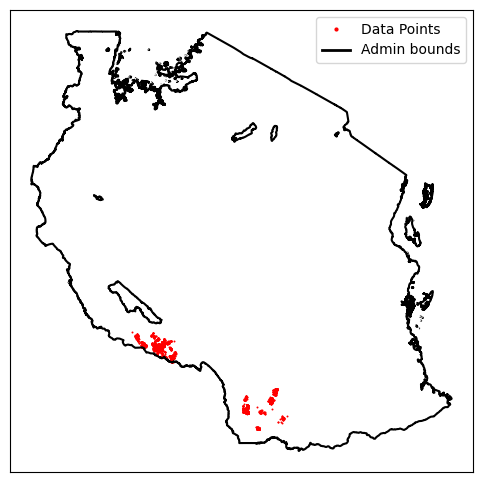

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
# gdf.loc[gdf.ADM3_EN.isin(data.FRMRward.unique())].plot(ax=ax, color='b')
points.plot(
    ax=ax, marker= 'o', linewidth=0, markersize=2,
    color='r'
)
boundary.plot(ax=ax, color='k')
ax.legend(handles=[
    # mpl.patches.Patch(color='b', label='Reported wards'),
    mpl.lines.Line2D([], [], color='r', marker='o', linestyle='None',
                           markersize=2, label='Data Points'),
    mpl.lines.Line2D([], [], color='k', linestyle='-',
                         linewidth=2, label='Admin bounds')
])
ax.set_xticks([]); ax.set_yticks([]);
# ax.set_xlim(.3e6, .9e6)
# ax.set_ylim(8.75e6, 9.05e6)

## Group the variables

We saw that we have data that reflects different crops. The reponder of the survey reports the data for their main crop. There are many variables that are crop specific. We will here find those variables by going over the metadata.

Overall, we identified a group of variables that reflects the field and responder characteristics. There is also a group of variables associated to fertilizer management. There are groups of variables for four main crops: maize, groundnuts, soya, and beans.

In [12]:
field_columns = [
    'fmba_campaign_year', 'FRMRgender', 'FRMRregion', 'FRMRdistrict',
    'FRMRward', 'previousadvice', 'mainharvestcrop', 'minorharvestcrop',
    'crophistory', 'crophistory_cropnumber', 'crophistory_intercrop',
    'fieldslope', 'landscape', 'soil_texture', 'est_harvestarea_ha',
    'gpsharvestarea_corrected_ha', 'area_diff_m2', 'harvestarea_ha',
    # Residues refer to last season, that's why it goes on field data
    'maizeresidues', 'beansresidues', 'gnutsresidues', 'soyaresidues', 

    'instanceID', 'surveyDate', 'start', 'end', 'PHONEmodel', 'PHONEcode', 
    'is_revisit', 'is_splitted', 'is_duplicated', 'n_overlap',
    'id_unique', 'id_cross', 'is_duplicated_multiple', 'is_duplicated_saved',
    'is_tiny_area', 'geometry'
]
maize_columns = [
    'maizeprodkg_ha', 'maizemarketing',
    'maizeharvest_seperate', 'maizeharvestsheller', 'maizevariety',
    'maizerecycledseed', 'maizefieldprep', 'maizeplantingmethod',
    'maizeplantmonth', 'maizeplantmonthpart', 'maizedryplant',
    'maizePdeficiency', 'maizeKdeficiency', 'maizeherbicides',
    'maizeweedings', 'maizepestdisease', 'maizekgseed_ha'
]
beans_columns = [
    'beans1prodkg_ha', 'beans1plantmonth', 'beans1plantmonthpart',
    'beans1_harvestmeasure', 'beansvariety1', 'beans1marketing', 
    'beansseedsource1', ''

    'beans2prodkg_ha', 'beans2plantmonth', 'beans2plantmonthpart', 
    'beans2_harvestmeasure', 'beansvariety2', 'beans2marketing', 
    'beansseedsource2', 
    
    'beans3prodkg_ha', 'beans3plantmonth', 'beans3plantmonthpart', 
    'beans3_harvestmeasure', 

    'beansfieldprep', 'beanplantingmethod', 'beansKdeficiency', 
    'beansherbicides', 'beansweedings', 'numberbeansharvests', 
    'beanspests', 'beansdiseases', 'kgbeansseed_ha',   
]
soya_columns = [
    'soyaprodkg_ha', 'soyaprodkg', 'soyavariety', 'soyaseedsource',
    'soyafieldprep', 'soyaplantingmethod', 'inoculant_awareness', 
    'inoculantfreq', 'inoculant_use', 'inoculanttype', 'inoculantpackets',
    'soyaplantmonth', 'soyaplantmonthpart', 'soyaPdeficiency', 
    'soyaKdeficiency', 'soyaherbicides', 'soyaweedings', 'soyapests',
    'soyadiseases', 'soyapesttypes', 'numsoyapests', 'soyadiseasetypes',
    'numsoyadiseases', 'kgsoyaseed_ha', 
]
gnuts_columns = [
    'gnutsprodkg_ha', 'gnuts_harvestmeasure', 'gnuts_shellstatus', 
    'gnutsmarketing', 'gnutsseedsource', 'gnutsfieldprep', 
    'gnutsplantingmethod', 'gnutsplantmonth', 'gnutplantmonthpart', 
    'gnutsherbicides', 'gnutsweedings', 'gnutspests', 'gnutsdiseases', 
    'kggnutsseed_ha',    
]
fertilizer_columns = [
    'manurefreq', 'manure', 'fertiliser_use', 'basal_application',
    'basaltypes', 'KGbasal_ha', 'KGNbasal_ha', 'KGPbasal_ha', 'KGKbasal_ha',
    'TShbasal_ha', 'topnumber', 'top1timing', 'top1application',
    'top1types', 'KGtop1_ha', 'KGNtop1_ha', 'KGPtop1_ha', 'KGKtop1_ha',
    'TShtop1_ha', 'top2timing', 'top2application', 'top2types', 'KGtop2_ha',
    'KGNtop2_ha', 'KGPtop2_ha', 'KGKtop2_ha', 'TShtop2_ha', 'top3timing',
    'top3application', 'top3types', 'KGtop3_ha', 'KGNtop3_ha', 'KGPtop3_ha',
    'KGKtop3_ha', 'TShtop3_ha', 'KGtop_ha', 'KGNtop_ha', 'KGPtop_ha',
    'KGKtop_ha', 'TShtop_ha', 'KGtotal_ha', 'KGNtotal_ha', 'KGPtotal_ha',
    'KGKtotal_ha', 'TShtotal_ha', 'nomaizefertilisers',
    'KGnomaizefertiltype1_ha', 'KGnomaizefertiltype2_ha',
    'KGnomaizefertil_ha', 'KGNnomaizefertil_ha', 'KGPnomaizefertil_ha',
    'KGKnomaizefertil_ha', 'TShnomaizefertil_ha'
]

There are a couple variables than won't be included as there are almost no reponses in such variables, or do not belong to any of the previously defined groups.

In [13]:
set(data.columns) - set(field_columns + maize_columns + soya_columns + gnuts_columns + fertilizer_columns + beans_columns)

{'fieldID',
 'herbicides',
 'minorcrop_harvestmeasure',
 'othermaincrop_harvestmeasure',
 'othermaincropprodkg_ha',
 'otherminorcropprodkg_ha',
 'weedings'}

In [14]:
data = data.set_index('fieldID')

In [15]:
# This dataframe is to be used on the Phenology assessment
data_maize_soya = data[data.mainharvestcrop.isin(['maize', 'soya'])]
data_maize_soya.to_pickle('../data-definitive/raw/data-maize-soya-raw.pkl')

In [16]:
data = data_maize_soya

## Include external covariates

On the `soil-data.py` and `weather-data.py` scripts we have sampled some Weather and Soil data for the sample points. In the case of soil, the soil properties for two layers (0-20, 20-50cm) are averaged for a 90mx90m area centered on the point. In the case of Weather, we have a time-series for each point from the AgERA5 dataset.

### Soil data

The soil data is saved in a df that shares the same index as the original data. We will select only the variables for the 0-20 cm layer.

In [17]:
soil_data = pd.read_pickle('../data-definitive/external-covs/soil-data.pkl')
soil_vars = [
    'nitrogen_total_mean_0_20', 'clay_content_mean_0_20', 'sand_content_mean_0_20', 
    'bulk_density_mean_0_20', 'cation_exchange_capacity_mean_0_20', 
    'ph_mean_0_20', 'carbon_organic_mean_0_20'
]
soil_data = soil_data[soil_vars]
soil_data.describe()

,nitrogen_total_mean_0_20,clay_content_mean_0_20,sand_content_mean_0_20,bulk_density_mean_0_20,cation_exchange_capacity_mean_0_20,ph_mean_0_20,carbon_organic_mean_0_20
count,3753.000000,3753.000000,3753.000000,3753.000000,3753.000000,3753.000000,3753.000000
mean,66.744175,29.571572,53.275246,133.096456,25.412529,58.208692,23.754152
std,9.472152,4.293387,5.289547,5.043524,1.413851,1.363706,1.860144
min,42.000000,17.222222,40.222222,105.111111,20.000000,54.000000,18.777778
25%,60.111111,26.777778,49.777778,131.000000,24.444444,57.222222,22.444444
50%,66.666667,30.444444,52.333333,134.333333,25.333333,58.222222,23.444444
75%,73.333333,32.444444,55.777778,136.222222,26.444444,59.111111,25.000000
max,113.222222,40.777778,72.222222,146.666667,29.666667,64.000000,31.000000


### Weather data

For the case of weather data we have a timeseries for each point. We need to summarize that timeseries by creating indices. Also, we need to determine what will be the time period to consider. We estimated the start and end of the season using Sentinel satellite images. This was done only for the fields where maize and soya was planted. Now on, we will only focus on maize data.

In [19]:
phenology = pd.read_pickle('../data-definitive/external-covs/maize-soya-phenology.pkl')

In [20]:
data.loc[data.mainharvestcrop == 'maize', 'maizevariety'].value_counts()

maizevariety
SC719                      839
PAN691                     382
SC627                      157
LOCAL_VARIETY              144
DKC9089                    115
SC403                       47
PAN53                       43
UH6303                      39
CANNOT-REMEMBER-VARIETY     22
DK777                       22
ZMS606                      20
MERU_HB513                  16
UH615                       15
PHB3253                     12
PHB30G19                    11
MERU_HB623                  10
SY6444                       8
DKC8053                      5
ZMS402                       5
PIONEER3812                  5
PAN15                        5
UNKNOWN_VARIETY              4
LUBANGO                      3
ZMS638                       2
SC513                        2
SY634                        2
SC413                        1
SC727                        1
PAN3M-01                     1
PAN4M-21                     1
Name: count, dtype: int64

In [21]:
data.loc[data.mainharvestcrop == 'soya', 'soyavariety'].value_counts()

soyavariety
local        420
Uyole04      181
Uyole02       19
dontknow       9
SC_Safari      2
SC_Squire      1
SC_Semeke      1
Name: count, dtype: int64

We have information on the start of season and end of season. We will split the season in 10. Then, each of the splits will be assumed to match the timing of the different management tasks.

We will summarize for those two periods:
- Average mean, max, and min temperature
- Average solar radiation
- Total precipitation
- Fraction of days with rain
- Lenght of maximum dry-spell

In [22]:
# Bring the weather data
weather_data_daily = pd.read_pickle('../data-definitive/external-covs/weather-data-daily-2024-linearinterp.pkl')
weather_data_daily.columns = ['tmean', 'tmax', 'tmin', 'vp', 'prec', 'srad', 'ws']
weather_data_daily['tmean'] -= 273.15
weather_data_daily['tmax'] -= 273.15
weather_data_daily['tmin'] -= 273.15
weather_data_daily['srad'] /= 1e6
weather_data_daily.head()

tmean       tmax       tmin         vp  prec  \
nEDtlpqrbz 2023-06-01  19.516522  25.210625  13.799217  14.560925  0.00   
           2023-06-02  20.242815  25.110737  14.620455  16.395666  0.64   
           2023-06-03  19.392033  23.778739  15.955541  17.127893  1.31   
           2023-06-04  18.978095  23.757201  14.473910  16.175912  0.64   
           2023-06-05  19.442955  24.453416  13.998166  16.496855  0.77   

                            srad        ws  
nEDtlpqrbz 2023-06-01  16.046720  1.610233  
           2023-06-02  15.987688  1.704558  
           2023-06-03  15.304339  1.894500  
           2023-06-04  14.504516  1.917471  
           2023-06-05  16.239324  1.916573

In [23]:
rain_threshold = 1
def get_weather_vars(idx):
    tmp_df = weather_data_daily.loc[idx]
    if idx not in phenology.index:
        season_dates = pd.date_range('2023-12-01', '2024-05-31')
    else:
        season_dates = pd.date_range(phenology.loc[idx, 'estimated_sos'], phenology.loc[idx, 'estimated_eos'])
    periods = {
        f'{(i*10)}to{10*(i+1)}perc_season': dates
        for i, dates in zip(range(0, 10), np.array_split(season_dates, 10))
    }
    vars_dict = {}
    for per_name, per in periods.items():
        # for var in ['tmin', 'tmean', 'tmax', 'srad']:
        for var in ['tmean', 'srad']:
            vars_dict[f'{per_name}_{var}'] = tmp_df[var].loc[per].mean()
        # As the season lenght and period is variable, then it's better to have mean precipitation
        # instead of sum. Mean would be a way to normalize for season lenght. 
        vars_dict[f'{per_name}_prec'] = tmp_df.loc[per, 'prec'].mean() 
        vars_dict[f'{per_name}_rainydays'] = (tmp_df.loc[per, 'prec'] > rain_threshold).mean()
        # vars_dict[f'{per_name}_maxdryspell'] = (tmp_df.loc[per, 'prec'] > rain_threshold).cumsum().value_counts().max() - 1
        # vars_dict[f'{per_name}_avgdryspell'] = (tmp_df.loc[per, 'prec'] > rain_threshold).cumsum().value_counts().mean() - 1
        
    per_name = '0to100perc_season'
    for var in ['tmean', 'srad']:
        vars_dict[f'{per_name}_{var}'] = tmp_df[var].loc[season_dates].mean()
    vars_dict[f'{per_name}_prec'] = tmp_df.loc[season_dates, 'prec'].mean()
    vars_dict[f'{per_name}_rainydays'] = (tmp_df.loc[season_dates, 'prec'] > rain_threshold).mean()
    return vars_dict

In [24]:
weather_data = pd.DataFrame.from_dict({
    i: get_weather_vars(i)
    for i in data.index
}, orient='index')

In [25]:
weather_data.describe()

,0to10perc_season_tmean,0to10perc_season_srad,0to10perc_season_prec,0to10perc_season_rainydays,10to20perc_season_tmean,10to20perc_season_srad,10to20perc_season_prec,10to20perc_season_rainydays,20to30perc_season_tmean,20to30perc_season_srad,...,80to90perc_season_prec,80to90perc_season_rainydays,90to100perc_season_tmean,90to100perc_season_srad,90to100perc_season_prec,90to100perc_season_rainydays,0to100perc_season_tmean,0to100perc_season_srad,0to100perc_season_prec,0to100perc_season_rainydays
count,2574.000000,2574.000000,2574.000000,2574.000000,2574.000000,2574.000000,2574.000000,2574.000000,2574.000000,2574.000000,...,2574.000000,2574.000000,2574.000000,2574.000000,2574.000000,2574.000000,2574.000000,2574.000000,2574.000000,2574.000000
mean,21.996532,18.007184,10.265887,0.842851,21.185852,15.809677,12.802764,0.944943,21.235719,16.838169,...,0.274415,0.053266,18.223638,19.091774,0.100802,0.020269,20.305317,17.452916,6.733986,0.584522
std,1.451643,2.505091,3.809275,0.130891,1.464148,1.895340,2.829733,0.084964,1.312773,1.391286,...,0.747504,0.103991,1.092754,1.749222,0.558917,0.058123,1.035793,0.685285,1.247820,0.086866
min,16.814889,11.528855,2.655608,0.210526,16.917150,12.293797,1.559000,0.272727,17.279023,12.674714,...,0.000000,0.000000,12.843494,13.482856,0.000000,0.000000,15.819138,15.906199,0.845361,0.159817
25%,21.098422,15.928353,7.070952,0.739130,19.897547,14.350502,11.163654,0.933333,20.123793,15.906052,...,0.022938,0.000000,17.528553,17.745926,0.007368,0.000000,19.632634,16.873023,5.884886,0.526404
50%,21.875126,18.196648,10.296752,0.868116,21.597074,15.346863,13.005385,1.000000,21.537456,17.064365,...,0.083684,0.000000,18.240743,19.615108,0.026517,0.000000,20.388529,17.387752,6.699412,0.586667
75%,23.055469,20.221755,12.996404,0.952381,22.079944,17.158305,14.557391,1.000000,22.160770,17.786409,...,0.195353,0.052632,18.930883,20.406232,0.094444,0.000000,20.921899,18.020232,7.600361,0.647668
max,26.048213,22.568907,24.301177,1.000000,26.078703,23.536406,24.313000,1.000000,25.520888,22.199452,...,23.814445,1.000000,23.623382,23.574626,16.234444,1.000000,24.124852,19.727956,14.048140,0.884615


In [26]:
data = data.join(soil_data).join(weather_data)
data = data.join(phenology.drop(columns='mainharvestcrop'))

## Inaccessibility index and elevation

In [27]:
inindex = pd.read_csv('../data-definitive/external-covs/inaccessibility-index.csv')
inindex = inindex.set_index('fieldID')
inindex.columns = ['innacessibility_index']
inindex = inindex.fillna(inindex.min())
elevation = pd.read_csv('../data-definitive/external-covs/elevation.csv')
elevation = elevation.set_index('fieldID')
elevation.columns = ['elevation']
data = data.join(elevation).join(inindex)

In [28]:
data.groupby('mainharvestcrop').KGnomaizefertiltype2_ha.describe()

,count,mean,std,min,25%,50%,75%,max
mainharvestcrop,,,,,,,,
maize,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
soya,2.0,102.013169,36.803061,75.989475,89.001322,102.013169,115.025016,128.036863


In [29]:
# drop columns that don't contain relevant information because it is an unique value, 
# there are only a few records, or are variables derived from some others
columns_to_drop =[
    'fmba_campaign_year', 'FRMRregion', 'FRMRdistrict', 'FRMRward',
    'minorharvestcrop', 'crophistory_intercrop',
    'surveyDate', 'start', 'end', 'PHONEmodel', 'PHONEcode',
    'is_splitted', 'is_duplicated', 'n_overlap', 'id_unique', 'id_cross',
    'is_duplicated_multiple', 'is_duplicated_saved', 'is_tiny_area',
]
data = data.drop(columns=columns_to_drop)

In [30]:
data.to_pickle('../data-definitive/raw/data-maize-soya.pkl')

In [31]:
data.previousadvice.value_counts()

previousadvice
no     2120
yes     454
Name: count, dtype: int64

The crop production is the outcome the treatment affects. Let's see how does the treatment seems to affect the crop production:

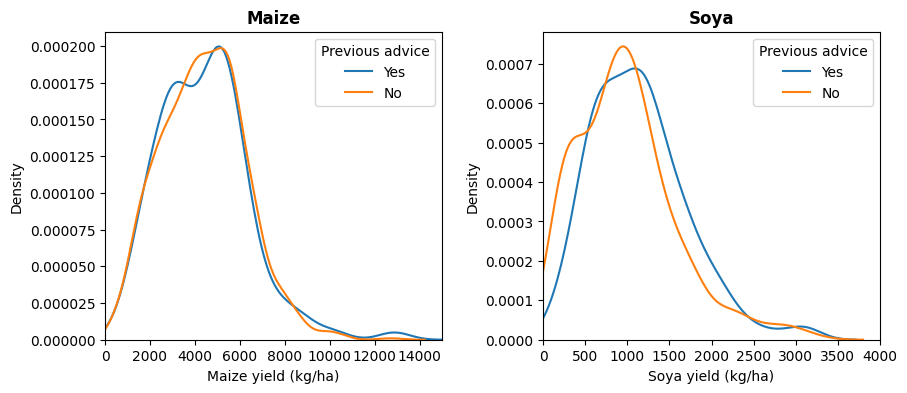

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes[0]
sns.kdeplot(
    data.loc[data.previousadvice == 'yes'],
    x='maizeprodkg_ha', ax=ax, label='Yes'
)
sns.kdeplot(
    data.loc[data.previousadvice == 'no'],
    x='maizeprodkg_ha', ax=ax, label='No'
)
ax.legend(title='Previous advice')
ax.set_xlim(0, 15000)
ax.set_xlabel('Maize yield (kg/ha)')
ax.set_title('Maize', fontweight='bold')

ax = axes[1]
sns.kdeplot(
    data.loc[data.previousadvice == 'yes'],
    x='soyaprodkg_ha', ax=ax, label='Yes'
)
sns.kdeplot(
    data.loc[data.previousadvice == 'no'],
    x='soyaprodkg_ha', ax=ax, label='No'
)
ax.legend(title='Previous advice')
ax.set_xlim(0, 4000)
ax.set_xlabel('Soya yield (kg/ha)')
ax.set_title('Soya', fontweight='bold')

plt.subplots_adjust(wspace=.3)

# Cleaning

In [33]:
data_not_clean = data.copy()
data = data.replace({'none': None, 'None': None, 'NONE': None, 'NAN': None, 'NaN': None})

In [34]:
# Check if there are records with both maize and soya production data
data[data.maizeprodkg_ha.notna() & data.soyaprodkg_ha.notna()]

,FRMRgender,previousadvice,mainharvestcrop,crophistory,crophistory_cropnumber,fieldslope,landscape,soil_texture,est_harvestarea_ha,gpsharvestarea_corrected_ha,...,estimated_sos,estimated_eos,estimated_los,peak_ndvi_time,peak_ndvi_value,sos_ndvi_value,eos_ndvi_value,ndvi_array_j,elevation,innacessibility_index
fieldID,,,,,,,,,,,,,,,,,,,,,
W0Np8wggre,Mr,no,maize,maize,1,little-slope,hillside,clay-loam,0.64978,0.682349,...,2023-12-16,2024-08-01,229.0,2024-03-23,0.767944,0.333138,0.29229,3149,1087.0,0.796547


In [35]:
# We will drop that record and we'll focus on records that have either maize or soya
# that way we can easily create a single production column
data = data[~(data.maizeprodkg_ha.notna() & data.soyaprodkg_ha.notna())]
(data.maizeprodkg_ha.notna() & data.soyaprodkg_ha.notna()).any()

np.False_

In [36]:
# list(filter(lambda x: 'top' in x, data.columns))

In [37]:
metadata.loc['top2types']

colindex                                                    128
coltype                                               character
n_distinct                                                   27
n_missing                                                  2584
mean                                                        NaN
median                                                      NaN
min                                                         NaN
max                                                         NaN
type                                            select_multiple
values        DAP / NPK-11|22|21 / NPK-14|23|14 / NPK-20|10|...
questn        What type(s) of fertiliser did you apply this ...
Name: top2types, dtype: object

In [38]:
# Assign amount of zero, when no fertilizer was applied
farmer_applied_fertilizer = data[f'basal_application'].notna()
for element in ('N', 'P', 'K', ''):
    data.loc[~farmer_applied_fertilizer, f'KG{element}basal_ha'] = 0

for i in range(1, 4):
    farmer_applied_fertilizer = data[f'top{i}application'].notna()
    for element in ('N', 'P', 'K', ''):
        data.loc[~farmer_applied_fertilizer, f'KG{element}top{i}_ha'] = 0

In [39]:
# Do Soya people applied fertilizer?
# If they did, then data is not recorded here
data.loc[data.mainharvestcrop == 'soya', 'KGtop_ha'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: KGtop_ha, dtype: float64

In [40]:
# However, there is some data in this other column, but it does not tell 
# something about timing or anything
data.loc[data.mainharvestcrop == 'soya', 'KGnomaizefertiltype1_ha'].describe()

count     42.000000
mean     131.410595
std       74.202668
min        0.000000
25%       94.056364
50%      127.498496
75%      149.787710
max      368.703725
Name: KGnomaizefertiltype1_ha, dtype: float64

In [41]:
# Re-calculate total amounts
for element in ('N', 'P', 'K', ''):
    data[f'KG{element}total_ha'] = \
        data[[f'KG{element}basal_ha']+[f'KG{element}top{i}_ha' for i in range(1,4)]].sum(axis=1, skipna=False)

In [42]:
print('Records where fertilizer was applied but amount was not recorded')
farmer_applied_fertilizer = data[f'basal_application'].notna() 
applied_amount_recorded = data[f'KGbasal_ha'].notna() 
print(f'Basal: {(farmer_applied_fertilizer & ~applied_amount_recorded).sum()}/{len(data)}')
for i in range(1, 4):
    farmer_applied_fertilizer = data[f'top{i}application'].notna() 
    applied_amount_recorded = data[f'KGtop{i}_ha'].notna() 
    print(f'Top {i}: {(farmer_applied_fertilizer & ~applied_amount_recorded).sum()}/{len(data)}')

Records where fertilizer was applied but amount was not recorded
Basal: 66/2573
Top 1: 882/2573
Top 2: 596/2573
Top 3: 10/2573


In [43]:
data[[f'KG{e}total_ha' for e in ('N', 'P', 'K', '')]].describe()

,KGNtotal_ha,KGPtotal_ha,KGKtotal_ha,KGtotal_ha
count,1688.000000,1688.000000,1688.000000,1688.000000
mean,68.187675,16.865672,0.115997,234.351240
std,70.172508,21.479305,2.034576,241.853764
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,66.838617,0.000000,0.000000,232.343735
75%,116.559292,27.540063,0.000000,390.458070
max,401.262895,154.702326,58.954456,1253.946546


In [44]:
print('Records where fertilizer was applied but timing was not recorded')
for i in range(1, 4):
    farmer_applied_fertilizer = data[f'top{i}application'].notna()
    timing_recorded = data[f'top{i}timing'].notna()
    print(f'Top {i}: {(farmer_applied_fertilizer & ~timing_recorded).sum()}/{len(data)}')

Records where fertilizer was applied but timing was not recorded
Top 1: 0/2573
Top 2: 0/2573
Top 3: 0/2573


In [45]:
data.to_pickle('../data-definitive/maize-soya-clean.pkl')

# Check spatial auto-correlation

In [46]:
data['prodstd'] = (data.maizeprodkg_ha - data.maizeprodkg_ha.mean())/data.maizeprodkg_ha.std()
data['prodstd'] = data.prodstd.fillna(
    (data.soyaprodkg_ha - data.soyaprodkg_ha.mean())/data.soyaprodkg_ha.std()
)
points['prodstd'] = data.prodstd

<Axes: >

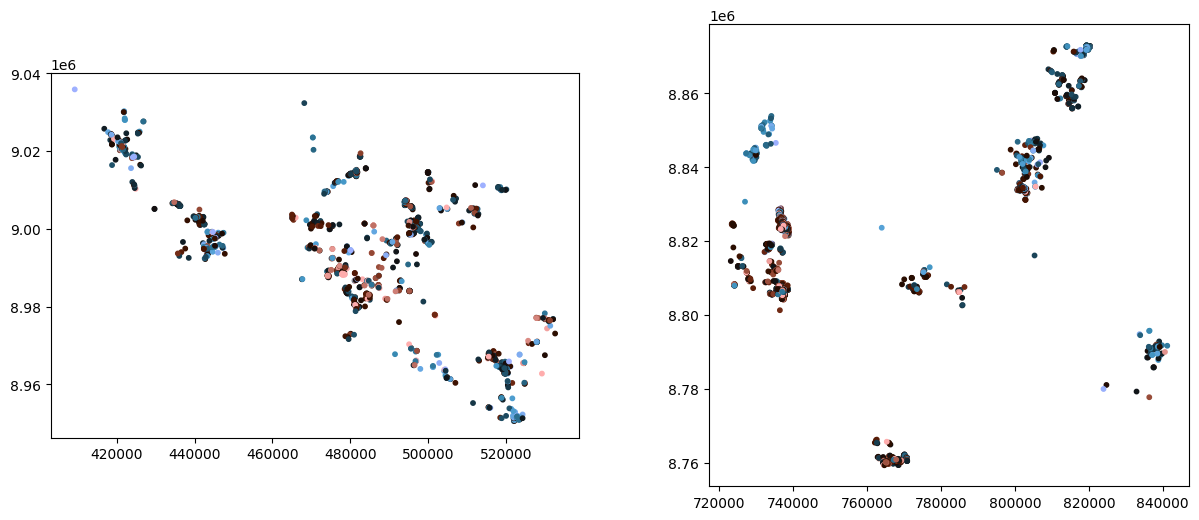

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
points.loc[points.geometry.x < 600000].plot(
    'prodstd', cmap='berlin', vmin=-1.9, vmax=1.9, s=10,
    ax=axes[0], alpha=1
)
# axes[0].set_facecolor('k'); axes[1].set_facecolor('k')
points.loc[points.geometry.x > 600000].plot(
    'prodstd', cmap='berlin', vmin=-1.9, vmax=1.9, s=10,
    ax=axes[1], alpha=1
)

<Axes: xlabel='prodstd', ylabel='Count'>

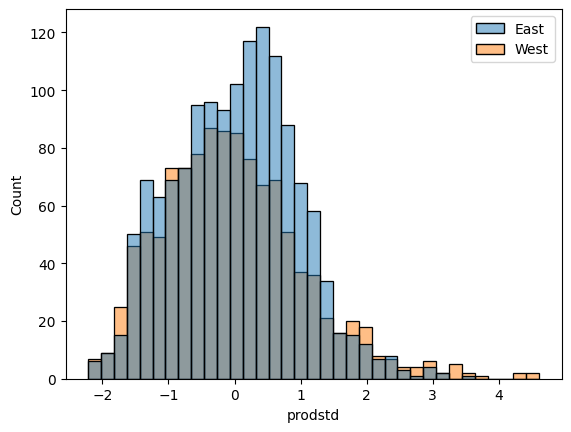

In [50]:
sns.histplot(
    points, x='prodstd',
    hue=np.where(points.geometry.x<6e5, 'West', 'East')
)

In [51]:
import skgstat as skg
points_nona = points.dropna()

In [52]:
points_tmp = points_nona.loc[points_nona.geometry.x < 6e5]
west_idxs = points_tmp.index
coords = np.array([points_tmp.geometry.x, points_tmp.geometry.y]).T
values = points_tmp.prodstd.to_numpy()
# fig, axes = plt.subplots(2, 1, height_ratios=(0.8, 0.2), sharex=True)
variogram_west = skg.Variogram(
    coords, values, model='matern', maxlag=50e3,
    n_lags=50, use_nugget=True, estimator='cressie'
)
points_tmp = points_nona.loc[points_nona.geometry.x > 6e5]
east_idxs = points_tmp.index
coords = np.array([points_tmp.geometry.x, points_tmp.geometry.y]).T
values = points_tmp.prodstd.to_numpy()
variogram_east = skg.Variogram(
    coords, values, model='matern', maxlag=50e3,
    n_lags=50, use_nugget=True, estimator='cressie'
)

Text(0.5, 1.0, 'East')

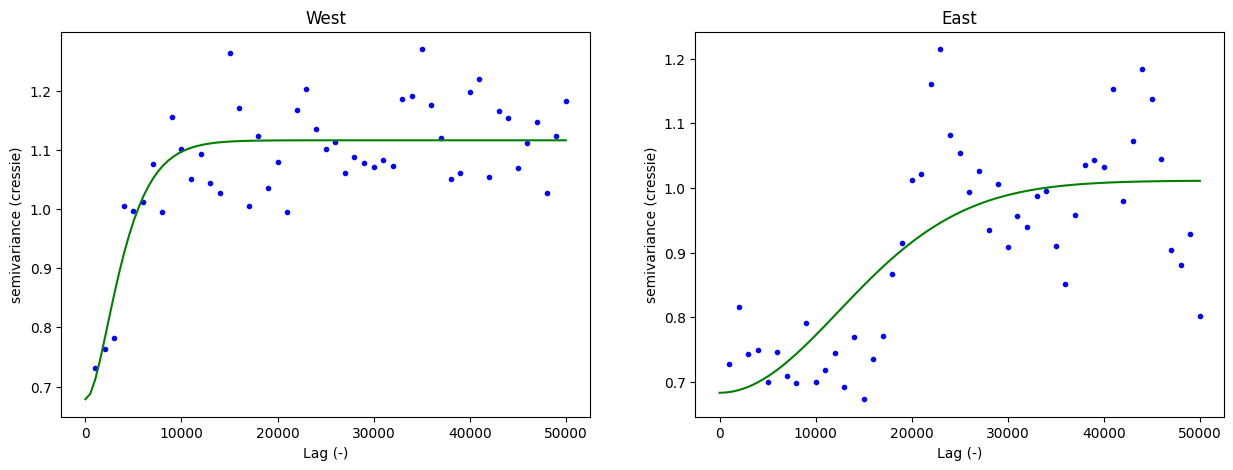

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
variogram_west.plot(axes=ax, hist=False, grid=False)
ax.set_title('West')
ax = axes[1]
variogram_east.plot(axes=ax, hist=False, grid=False)
ax.set_title('East')


In [54]:
from libpysal import weights
from esda.moran import Moran

In [55]:
w = weights.KNN.from_dataframe(points_nona, k=10)
moran_test = Moran(points_nona.prodstd, w)
moran_test.I, moran_test.p_rand

 There are 35 disconnected components.


(np.float64(0.2442367516715004), np.float64(4.280763528797755e-191))